# Assignment 2

### Question 1: *git* in Practice

- initialise a repository and push content to the *main* branch
- create and work on a brnach with a descriptive name
- make regular commits with meaninful commit messages
- merge your branch back into *main*

getting access to the gitHub - to be done in a shell
```bash
git clone git@github.com:u7496134/Assignment_2.git
```
This repository has been made using the template given at: https://github.com/svenbuder/template_ojap

### Question 2: Bright Stars Around M67 with ADQL

1. Write an ADQL query that returns all stars in the Gaia DR3 gaiadr3.gaia_source table within 1 degree of M67 with G < 14 and crossmatch them with 2MASS. Report the number of stars returned.

In [24]:
#%pip install astroquery
from astroquery.gaia import Gaia
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.optimize import*
import matplotlib.cm as cm
from io import StringIO
import os
from astropy.io import fits

Inputted query in the gaia catalogue:


SELECT 
	g.source_id,
	g.ra,
	g.dec,
	g.phot_g_mean_mag,
	g.parallax,
	g.bp_rp,
	t.designation,
	t.j_m,
	t.h_m,
	t.ks_m,
	t.ph_qual,
	DISTANCE(
   		POINT(132.825,11.8),
   		POINT(g.ra,g.dec)) AS ang_sep

FROM gaiadr3.gaia_source AS g

JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS x
	USING (source_id)

JOIN gaiadr3.tmass_psc_xsc_join AS xjoin
	USING (clean_tmass_psc_xsc_oid)

JOIN gaiadr1.tmass_original_valid AS t
	ON xjoin.original_psc_source_id = t.designation

WHERE 1 = CONTAINS(
   POINT(g.ra,g.dec),
   CIRCLE(132.825,11.8,1.0))

AND phot_g_mean_mag < 14
AND g.parallax IS NOT NULL
ORDER BY ang_sep ASC

Using this query, the data outputs from each catalogue was selected to avoid grabbing unnecessary columns - this is determined in the select function.
Distance specifies the point of focus for the search.
The next 3 lines join the various gaia directories from the dr3 and dr1 as dr3 does not contain the 2mass values however the naming conventions have changed throughout each data release so these steps are required.
WHERE creates a cone search looking for stars within 1 degree of the coordinate points and is followed by one of the final categorisations: for all stars less than 14 mag.

This gave a result of 1101 stars.

2. Identify stars with:
    - bad 2MASS photometry
    - non-positive values of Gaia parallax

In [8]:
# loading in the .csv file gotten from the query - stored in the data folder
full_dataset = pd.read_csv('data/assignment2-result.csv')

# assuming we want to cut out the bad photometry
first_cut = full_dataset[full_dataset["ph_qual"] == 'AAA']
final_cut = first_cut[first_cut["parallax"] > 0]

#Finding the number stars remaining
print(len(final_cut))

988


Upon removing the bad photometry and negative parallaxes we have 988 entries remaining - having removed 113 entries.

3. Create and save a two panel figure showing:
    - Gaia BP-RP vs absolute G magnitude
    - 2MASS J-Ks vs apparent H magnitude

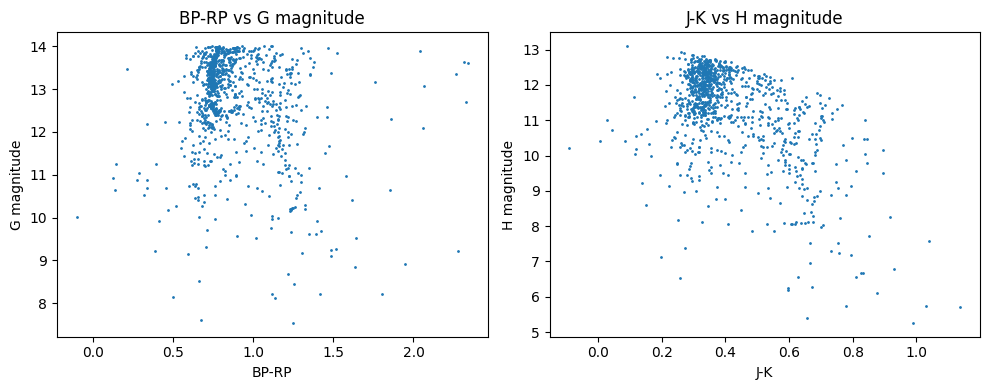

<Figure size 640x480 with 0 Axes>

In [21]:
# creating variables which store the required values
bp_rp = final_cut["bp_rp"] # holds only the specified column values
g_mag = final_cut["phot_g_mean_mag"]
j_m = final_cut["j_m"]
ks_m = final_cut["ks_m"]
h_m = final_cut["h_m"]

j_k = j_m - ks_m

# making the figure

fig, (b_g, jk_h) = plt.subplots(1,2,figsize=(10,4))

b_g.scatter(bp_rp,g_mag,s=1)
b_g.set_title("BP-RP vs G magnitude")
b_g.set_xlabel("BP-RP")
b_g.set_ylabel("G magnitude")

jk_h.scatter(j_k, h_m,s=1)
jk_h.set_title("J-K vs H magnitude")
jk_h.set_xlabel("J-K")
jk_h.set_ylabel("H magnitude")

plt.tight_layout()
plt.show()

# saving figure:
file_path = os.path.join('figures', 'q2_plots.png')
plt.savefig(file_path)


4. Based only upon fibre usage, would you recommend this field for a 2dF/HERMES observing proposal?

### Question 3: Radial Metallicity Relations Simulations

The radial metallicity relation describes the change of metallicity– here the gas-phase metallicity $A(O) = log_{10}(N_O/N_H) + 12$ -  with galactocentric cylindrical radius $R_{Gal}$.  Radial metallicity gradients provide insight into processes such as inside-out formation, gas accretion, outflows, and radial migration. A lot of work has been done through observational studies and a few simulations but more works is needed to understand variations of the radial metallicity gradient.

1. Plot a two-panel figure:
    -  logarithmic density plot of $R_{Gal}$. vs. A(O), with a linear fit and legend;
    -  residuals of the fit, $R_{Gal}$. vs. $∆A(O)$.

In [ ]:
# calling upon the file for use
data = fits.open("data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits")
metal_relations = np.array(data[1].data)

In [ ]:
# calculating R_{Gal}
r_gal = 


# plotting



In [50]:
metal_relations[0]


(10.020546, -15.421509, -3.241711, 8.42894319)

In [42]:
metal_relations

array([( 10.020546 , -15.421509  , -3.241711  , 8.42894319),
       (-13.487837 ,   5.6635065 , -0.8023056 , 8.67110685),
       (  6.642289 ,  -0.13894245, -0.5859607 , 8.89159578), ...,
       (  1.6982036,  -1.2077066 ,  0.12108785, 9.08120474),
       (  1.6982036,  -1.2066638 ,  0.12191749, 9.08120474),
       (  1.6980386,  -1.2066495 ,  0.12189952, 9.08120474)],
      dtype=(numpy.record, [('x', '>f4'), ('y', '>f4'), ('z', '>f4'), ('A_O', '>f8')]))